# W12

In [4]:
pip install dynesty

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from dynesty import NestedSampler
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
import corner
import warnings

In [6]:
data = np.load('/Users/lorenzaimpicicche/Desktop/astrostatistics_bicocca_2025/solutions/transient.npy')
t, flux, err=data[:, 0], data[:, 1], data[:, 2]

### burst model

In [7]:
def burst_model(t, b, A, t0, alpha):
    expo=np.clip(-alpha * (t - t0), -700, 700) # to avoid warning overflow
    return np.where(t<t0, b, b+A*np.exp(expo))

In [8]:
def log_likelihood(theta):
    b, A, t0, ln_alpha = theta
    alpha = np.exp(ln_alpha)
    model = burst_model(t, b, A, t0, alpha)
    return -0.5 * np.sum(((flux-model)/err)**2+np.log(2*np.pi*err**2))

In [9]:
def prior_transform(u):
    b=50*u[0]
    A=50*u[1]
    t0=100*u[2]
    ln_alpha=-5+10*u[3]  # ln_alpha ∈ [-5, 5]
    return [b, A, t0, ln_alpha]

In [10]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    dsampler_burst = NestedSampler(log_likelihood, prior_transform, ndim=4, nlive=500)
    dsampler_burst.run_nested()
res_burst = dsampler_burst.results

3211it [00:03, 380.18it/s, bound: 19 | nc: 13 | ncall: 31497 | eff(%): 10.195 | loglstar:   -inf < -179.485 <    inf | logz: -186.319 +/-  0.110 | dlogz: 36.528 >  0.509]/Users/lorenzaimpicicche/.pyenv/versions/3.10.11/lib/python3.10/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
3987it [00:11, 40.34it/s, bound: 92 | nc: 40 | ncall: 85875 | eff(%):  4.643 | loglstar:   -inf < -178.589 <    inf | logz: -185.321 +/-  0.107 | dlogz: 33.977 >  0.509]/Users/lorenzaimpicicche/.pyenv/versions/3.10.11/lib/python3.10/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal b

(<Figure size 1200x1200 with 8 Axes>,
 array([[<Axes: xlabel='$-\\ln X$', ylabel='b'>, <Axes: xlabel='b'>],
        [<Axes: xlabel='$-\\ln X$', ylabel='A'>, <Axes: xlabel='A'>],
        [<Axes: xlabel='$-\\ln X$', ylabel='t_0'>, <Axes: xlabel='t_0'>],
        [<Axes: xlabel='$-\\ln X$', ylabel='ln_alpha'>,
         <Axes: xlabel='ln_alpha'>]], dtype=object))

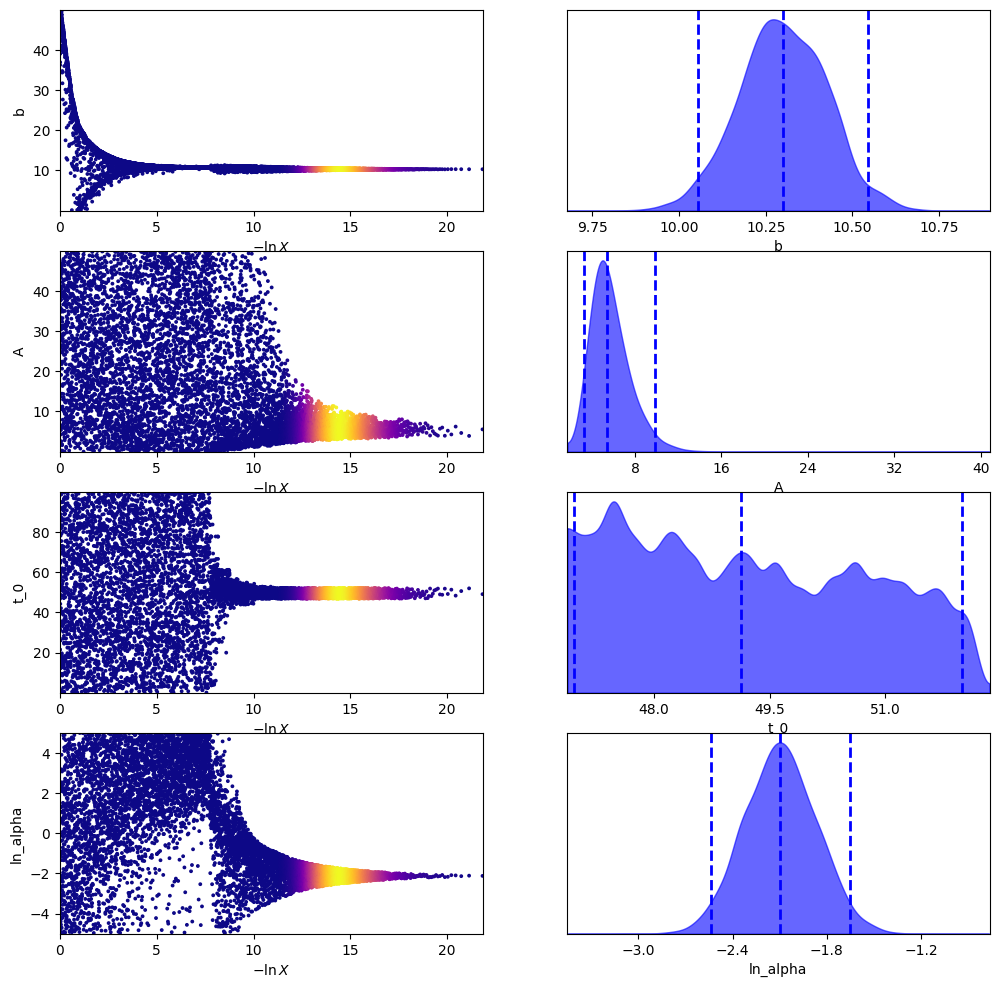

In [11]:
labels_burst = ["b", "A", "t_0", "ln_alpha"]
dyplot.traceplot(res_burst, labels=labels_burst)

(<Figure size 1600x1600 with 4 Axes>,
 array([<Axes: xlabel='$-\\ln X$', ylabel='Live Points'>,
        <Axes: xlabel='$-\\ln X$', ylabel='Likelihood\n(normalized)'>,
        <Axes: xlabel='$-\\ln X$', ylabel='Importance\nWeight PDF'>,
        <Axes: xlabel='$-\\ln X$', ylabel='Evidence'>], dtype=object))

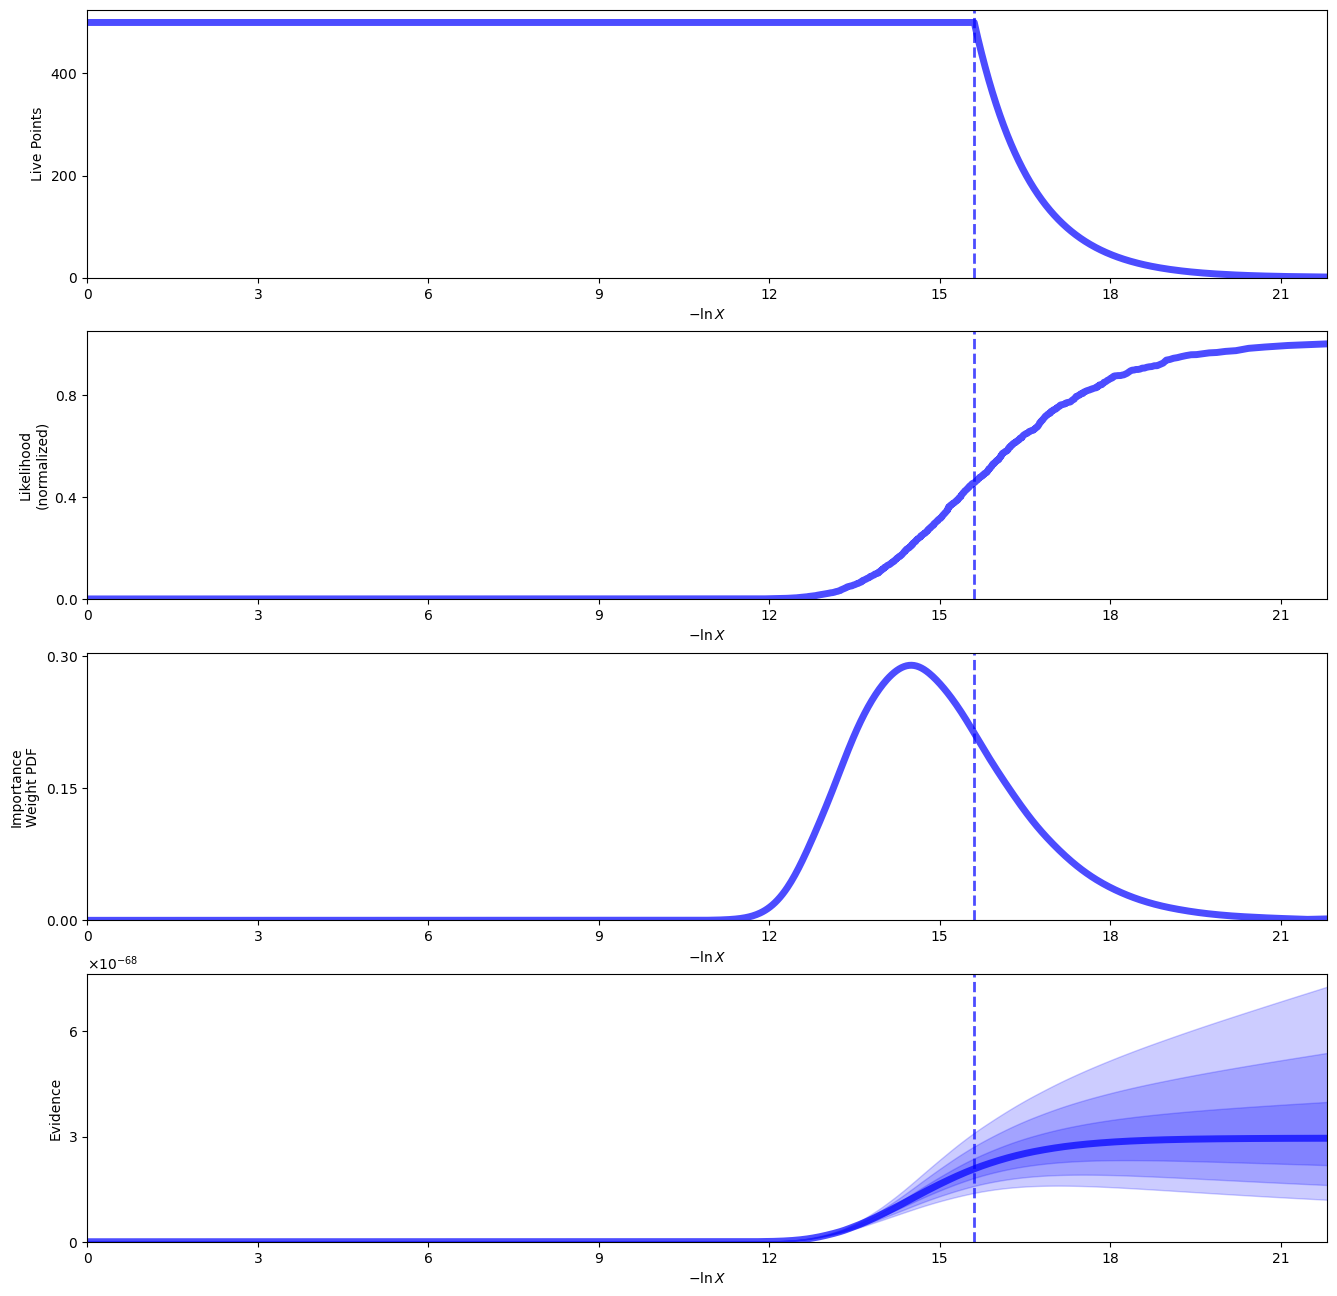

In [12]:
dyplot.runplot(res_burst)

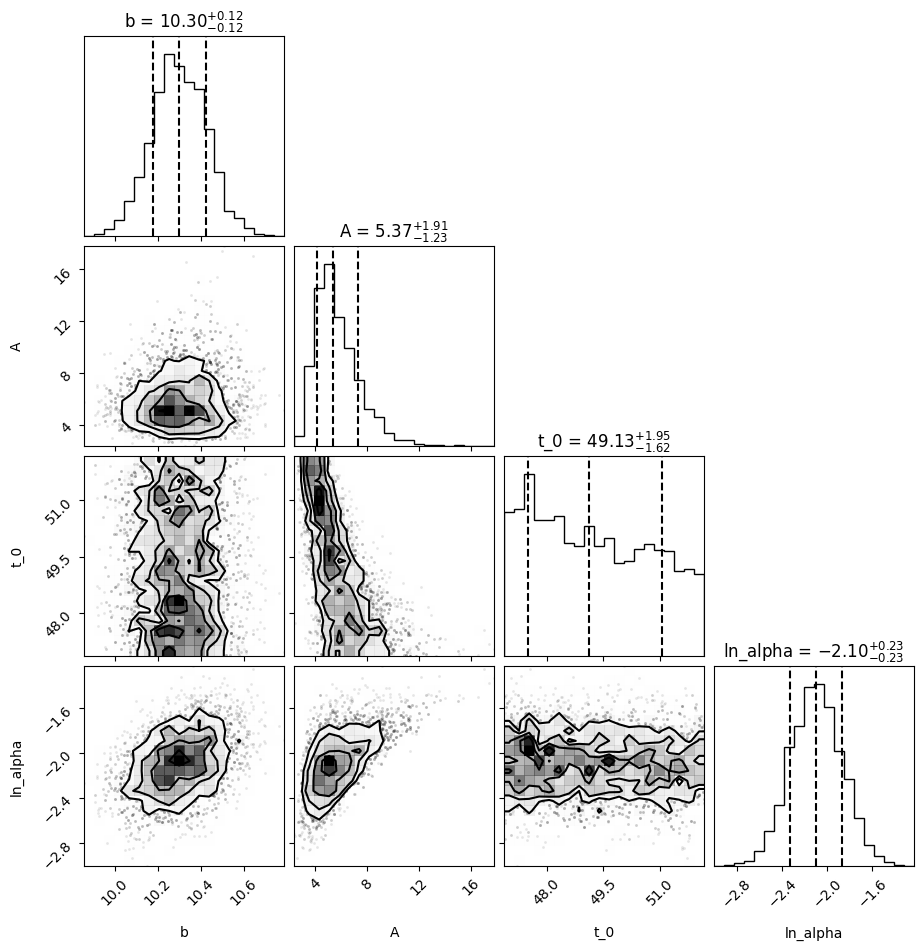

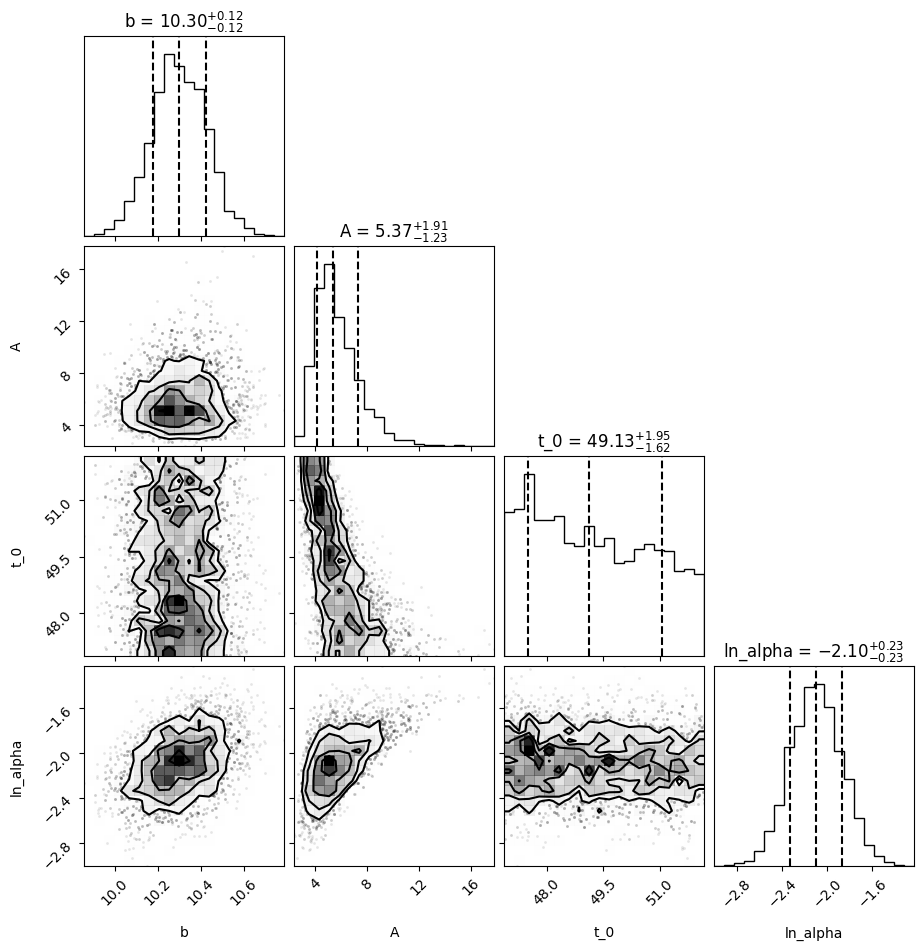

In [13]:
samples_burst = res_burst.samples
weights_burst = np.exp(res_burst.logwt - res_burst.logz[-1])
samples_equal_burst = dyfunc.resample_equal(samples_burst, weights_burst)

corner.corner(samples_equal_burst, labels=labels_burst, quantiles=[0.16, 0.5, 0.84],
              show_titles=True, title_fmt=".2f", title_kwargs={"fontsize": 12})

In [14]:
for i, lab in enumerate(labels_burst):
    q16, q50, q84 = dyfunc.quantile(samples_burst[:, i], [0.16, 0.5, 0.84], weights=weights_burst)
    print(f"{lab}: {q50:.3f} +{q84 - q50:.3f} -{q50 - q16:.3f}")

b: 10.300 +0.124 -0.123
A: 5.368 +1.910 -1.233
t_0: 49.126 +1.950 -1.624
ln_alpha: -2.096 +0.232 -0.232


### gaussian model

In [15]:
def gaussian_model(t, b, A, t0, ln_alpha, sigmaW):
    alpha = np.exp(ln_alpha)
    expo = np.clip(-alpha * ((t - t0) ** 2) / (2 * sigmaW ** 2), -700, 700)
    return b + A * np.exp(expo)

In [16]:
def log_likelihood_gauss(theta):
    b, A, t0, ln_alpha, sigmaW = theta
    model = gaussian_model(t, b, A, t0, ln_alpha, sigmaW)
    return -0.5 * np.sum(((flux - model) / err) ** 2 + np.log(2 * np.pi * err**2))

In [17]:
def prior_transform_gauss(u):
    b = 50 * u[0]
    A = 50 * u[1]
    t0 = 100 * u[2]
    ln_alpha = -5 + 10 * u[3]
    sigmaW = 0.1 + 19.9 * u[4]  # Uniform(0.1, 20)
    return [b, A, t0, ln_alpha, sigmaW]

In [18]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)

    dsampler_gauss = NestedSampler(
        log_likelihood_gauss,
        prior_transform_gauss,
        ndim=5,
        nlive=500,
        sample='rwalk', # improve the efficiency for posteriors
        bootstrap=0) # avoid the bootstrap that make the warning

    dsampler_gauss.run_nested()
res_gauss=dsampler_gauss.results

8412it [00:07, 1192.23it/s, +500 | bound: 90 | nc: 1 | ncall: 184078 | eff(%):  4.855 | loglstar:   -inf < -144.338 <    inf | logz: -160.432 +/-  0.179 | dlogz:  0.001 >  0.509]


(<Figure size 1200x1500 with 10 Axes>,
 array([[<Axes: xlabel='$-\\ln X$', ylabel='b'>, <Axes: xlabel='b'>],
        [<Axes: xlabel='$-\\ln X$', ylabel='A'>, <Axes: xlabel='A'>],
        [<Axes: xlabel='$-\\ln X$', ylabel='t_0'>, <Axes: xlabel='t_0'>],
        [<Axes: xlabel='$-\\ln X$', ylabel='ln_alpha'>,
         <Axes: xlabel='ln_alpha'>],
        [<Axes: xlabel='$-\\ln X$', ylabel='sigma_W'>,
         <Axes: xlabel='sigma_W'>]], dtype=object))

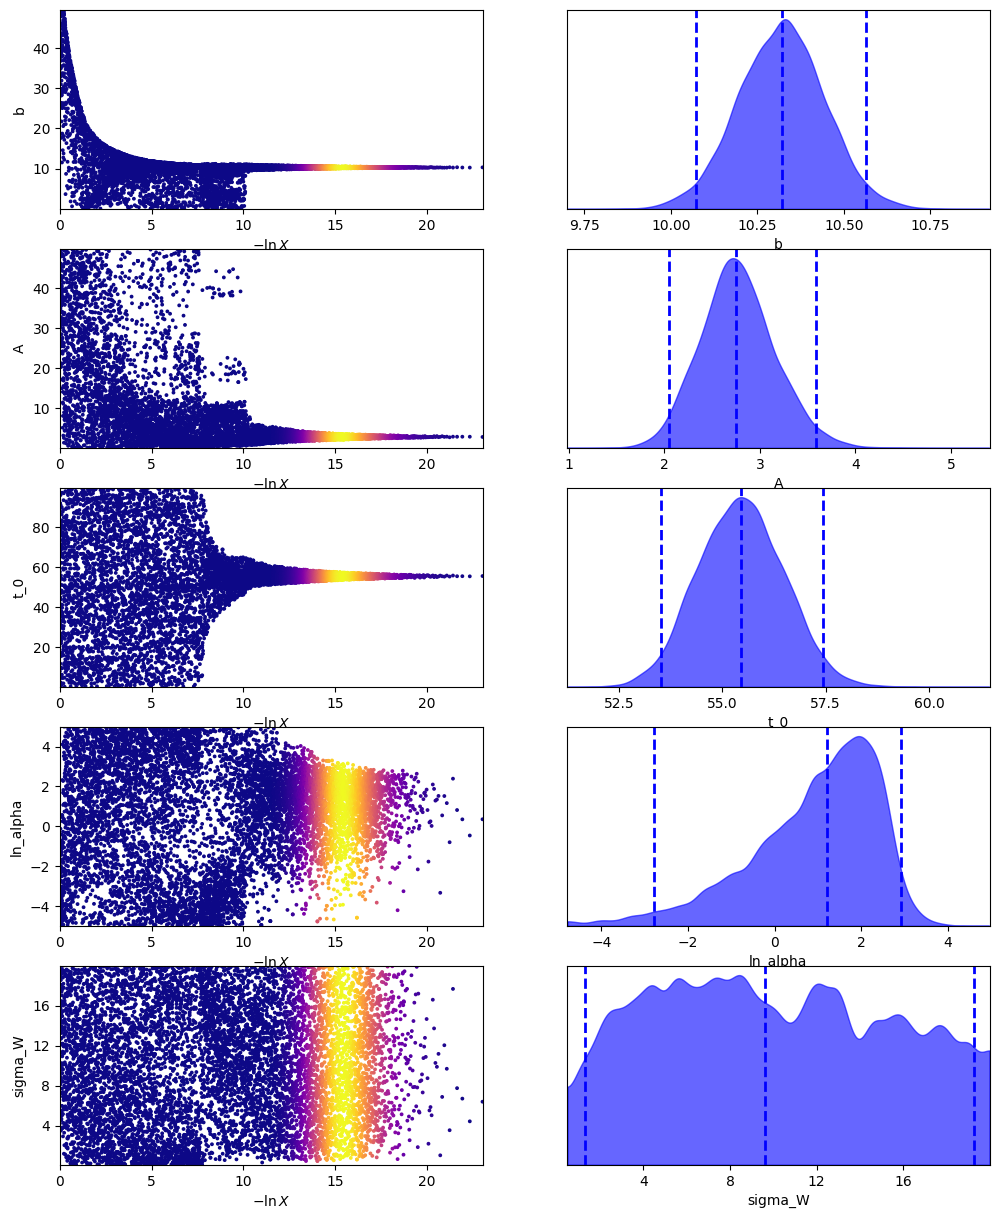

In [19]:
labels_gauss = ["b", "A", "t_0", "ln_alpha", "sigma_W"]
dyplot.traceplot(res_gauss, labels=labels_gauss)

(<Figure size 1600x1600 with 4 Axes>,
 array([<Axes: xlabel='$-\\ln X$', ylabel='Live Points'>,
        <Axes: xlabel='$-\\ln X$', ylabel='Likelihood\n(normalized)'>,
        <Axes: xlabel='$-\\ln X$', ylabel='Importance\nWeight PDF'>,
        <Axes: xlabel='$-\\ln X$', ylabel='Evidence'>], dtype=object))

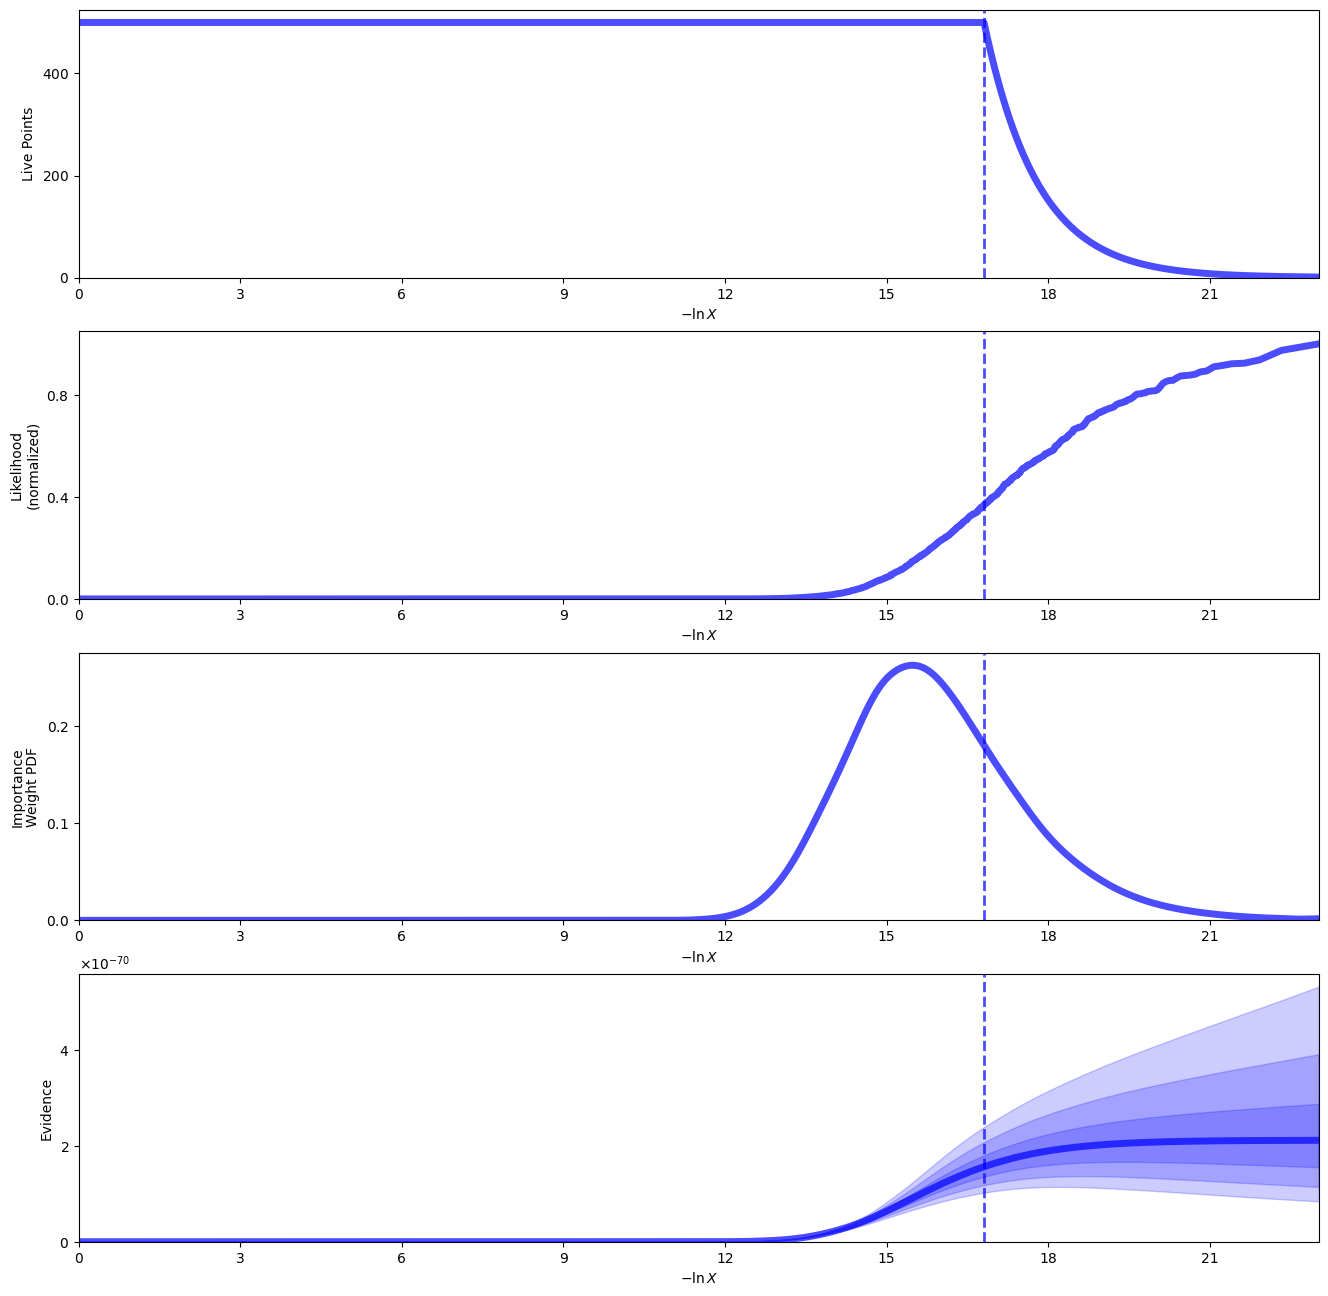

In [20]:
dyplot.runplot(res_gauss)

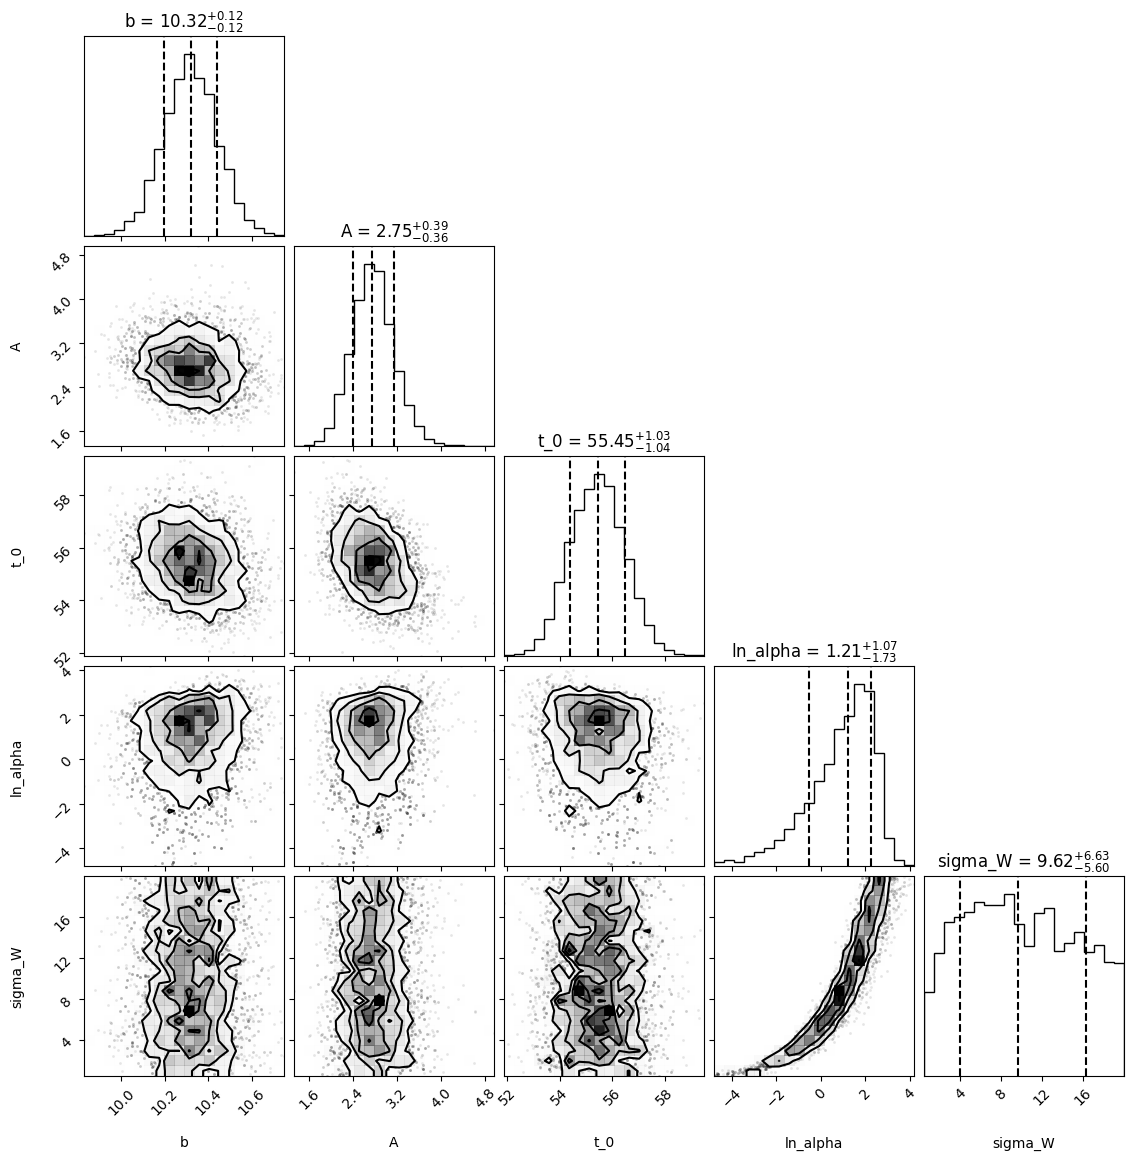

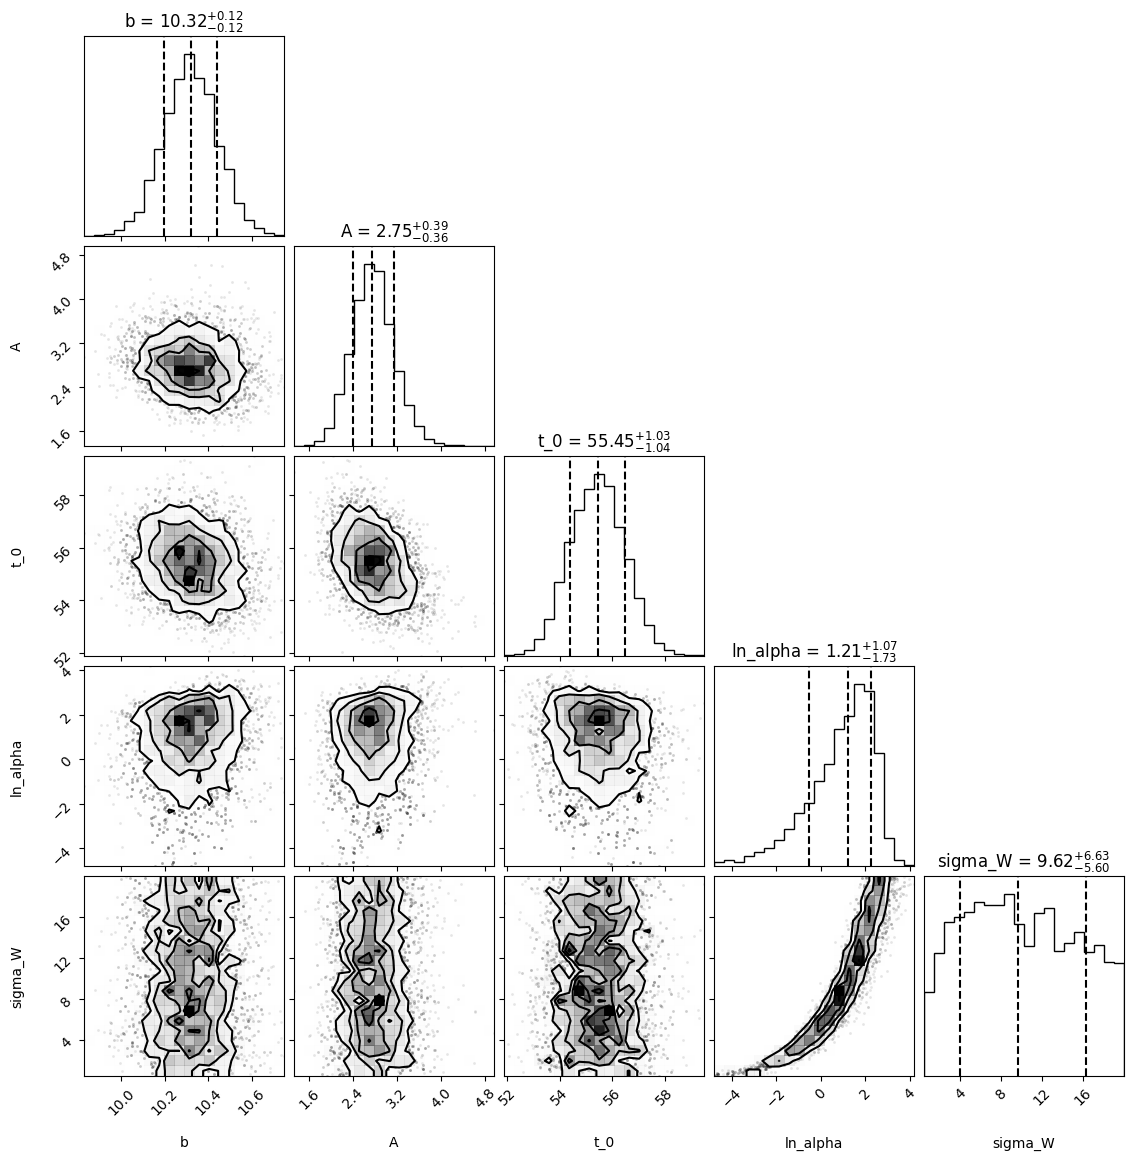

In [21]:
samples_gauss = res_gauss.samples
weights_gauss = np.exp(res_gauss.logwt-res_gauss.logz[-1])
samples_equal_gauss = dyfunc.resample_equal(samples_gauss, weights_gauss)

corner.corner(samples_equal_gauss, labels=labels_gauss, quantiles=[0.16, 0.5, 0.84],
              show_titles=True, title_fmt=".2f", title_kwargs={"fontsize": 12})

In [22]:
for i, lab in enumerate(labels_gauss):
    q16, q50, q84 = dyfunc.quantile(samples_gauss[:, i], [0.16, 0.5, 0.84], weights=weights_gauss)
    print(f"{lab}: {q50:.3f} +{q84 - q50:.3f} -{q50 - q16:.3f}")

b: 10.321 +0.119 -0.125
A: 2.751 +0.391 -0.361
t_0: 55.447 +1.024 -1.044
ln_alpha: 1.208 +1.076 -1.725
sigma_W: 9.622 +6.629 -5.602


In [23]:
res_burst.summary()
res_gauss.summary()


Summary
nlive: 500
niter: 7811
ncall: 158857
eff(%):  5.232
logz: -155.493 +/-  0.301
Summary
nlive: 500
niter: 8412
ncall: 183578
eff(%):  4.855
logz: -160.432 +/-  0.307


In [26]:
logZ_burst = res_burst.logz[-1]
logZ_gauss = res_gauss.logz[-1]

print(f"Bayes factor (burst/gauss): {np.exp(logZ_burst - logZ_gauss):.2f}")

Bayes factor (burst/gauss): 139.66


In [29]:
import dynesty.utils as dyfunc
samples_equal = dyfunc.resample_equal(samples_burst, weights_burst)
import dynesty.utils as dyfunc

samples_burst = res_burst.samples  # i samples dal nested sampling
weights_burst = np.exp(res_burst.logwt - res_burst.logz[-1])  # pesi normalizzati

samples_equal = dyfunc.resample_equal(samples_burst, weights_burst)


Text(0, 0.5, 'flux')

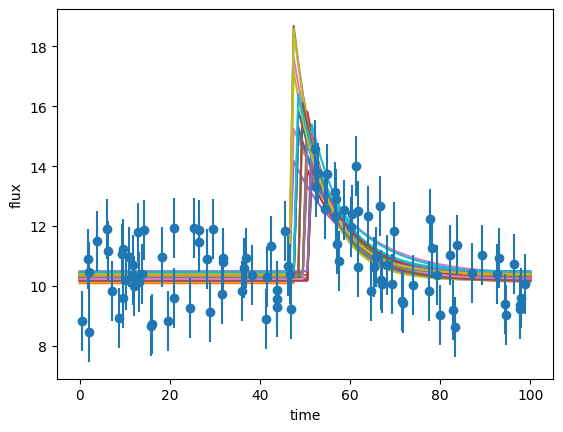

In [33]:
tgrid = np.linspace(0, 100, 100)

chosen_samples = samples_equal[np.random.choice(len(samples_equal), size=30, replace=False)]

for theta in chosen_samples:
    b, A, t0, ln_alpha = theta
    alpha = np.exp(ln_alpha)
    ygrid = np.where(tgrid < t0, b, b + A * np.exp(-alpha * (tgrid - t0)))
    plt.plot(tgrid, ygrid)
plt.errorbar(t, flux, yerr=err, fmt='o')
plt.xlabel("time")
plt.ylabel("flux")